# Group Tango -Telecom Customer Churn Prediction

## SECTION 0: Mount Google Drive

Before loading the dataset, we will connect Google Colab to our Google Drive. This allows Python to read the CSV file uploaded to Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## SECTION 1: Import All Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                    MinMaxScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


## SECTION 2: Load the Dataset
Load the Telecom Customer Churn dataset

In [ ]:
# Update this path to wherever you saved the file in your Drive
df = pd.read_csv('/content/drive/MyDrive/telecom_customer_churn.csv')

In [ ]:
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 7,043 rows × 38 columns


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## SECTION 3: General Dataset Information
Before any analysis or modelling, we need to understand what the dataset contains such as column names, data types, and which columns have missing values. This step is essential because it determines every preprocessing decision we will make.


### 3a. Column Types and Non-Null Counts

In [ ]:
# Show column names, data types, and how many non-null values exist
# Object = text/categorical; int64/float64 = numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

### 3b. Statistical Summary

The statistical summary gives us the range, mean, and spread of every numeric column. Extreme min or max values signal potential anomalies or outliers we must investigate.


In [ ]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


### 3c. Target Variable Distribution


Our target column is Customer Status. It has three categories: Stayed, Churned, and Joined. For binary classification we will define: **Churn = 1** (Churned), **Churn = 0** (Stayed or Joined). Understanding this distribution is critical because a heavily imbalanced dataset can mislead the model into predicting the majority class almost always.

In [ ]:
print("Customer Status Distribution:")
print(df['Customer Status'].value_counts())
print()
print("As percentages:")
print((df['Customer Status'].value_counts(normalize=True) * 100).round(2))

Customer Status Distribution:
Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

As percentages:
Customer Status
Stayed     67.02
Churned    26.54
Joined      6.45
Name: proportion, dtype: float64


> **Verified findings:** Stayed = 4,720 (67.0%), Churned = 1,869 (26.5%), Joined = 454 (6.4%). The dataset is moderately imbalanced, the model will see more non-churners than churners.


## SECTION 4: Missing Values, Duplicates & Anomalies


Missing values, duplicates, and anomalies (e.g. negative charges) must be identified and handled before any modelling. Carrying these forward corrupts results.


### 4a. Check for Missing Values


In [ ]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing values per column:
                                   Missing Count  Missing %
Offer                                       3877      55.05
Avg Monthly Long Distance Charges            682       9.68
Multiple Lines                               682       9.68
Internet Type                               1526      21.67
Avg Monthly GB Download                     1526      21.67
Online Security                             1526      21.67
Online Backup                               1526      21.67
Device Protection Plan                      1526      21.67
Premium Tech Support                        1526      21.67
Streaming TV                                1526      21.67
Streaming Movies                            1526      21.67
Streaming Music                             1526      21.67
Unlimited Data                              1526      21.67
Churn Category                              5174      73.46
Churn Reason                                5174      73.46


> **Findings:**
> - `Offer` 3,877 missing (55.1%): These are customers on no promotional offer. Missing = "No Offer".
> - `Internet Type`, `Avg Monthly GB Download`, and 8 internet-service columns 1,526 missing (21.7%): All correspond to customers with no internet service. Missing = "No Internet".
> - `Avg Monthly Long Distance Charges` and `Multiple Lines` 682 missing (9.7%): Customers with no phone service. Missing = 0 and "No Phone" respectively.
> - `Churn Category` and `Churn Reason` 5,174 missing: These are only filled for churned customers. We will drop these columns before modelling.

### 4b. Check for Duplicate Rows


In [ ]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

Duplicate rows found: 0


> **Verified:** 0 duplicate rows. No action needed.

### 4c. Check for Anomalies: Negative Charges


A Monthly Charge value below zero is a real-world anomaly, likely credits or billing errors. We will identify and handle these before modelling.


In [ ]:
neg_charges = (df['Monthly Charge'] < 0).sum()
print(f"Rows with negative Monthly Charge: {neg_charges}")
print(f"Minimum Monthly Charge value: {df['Monthly Charge'].min()}")

Rows with negative Monthly Charge: 120
Minimum Monthly Charge value: -10.0


> **Verified:** 120 rows have negative Monthly Charge (min = -10.0). These are anomalous and will be clipped to 0.

## SECTION 5: Data Cleaning & Preprocessing

We now systematically handle all issues found in Section 4. The order matters; fill missing values first, fix anomalies, create the binary target, then drop columns we will not use in modelling.


### 5a. Fill Missing Values


In [ ]:
# Create a working copy — never modify the original loaded dataframe
df_clean = df.copy()

# Offer: NaN means no promotional offer was applied
df_clean['Offer'] = df_clean['Offer'].fillna('No Offer')

# Internet Type and all internet-service features:
# NaN means the customer has no internet service
internet_cols = ['Internet Type', 'Avg Monthly GB Download', 'Online Security',
                 'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
                 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data']
for col in internet_cols:
    df_clean[col] = df_clean[col].fillna('No Internet')

# Phone-related: NaN means no phone service
df_clean['Multiple Lines'] = df_clean['Multiple Lines'].fillna('No Phone')
df_clean['Avg Monthly Long Distance Charges'] = \
    df_clean['Avg Monthly Long Distance Charges'].fillna(0)

print("Missing values remaining after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values remaining after cleaning:
Churn Category    5174
Churn Reason      5174
dtype: int64


### 5b. Fix Negative Monthly Charge Anomaly

In [ ]:
# Clip negative Monthly Charge values to 0
# A charge below zero is not economically meaningful
df_clean['Monthly Charge'] = df_clean['Monthly Charge'].clip(lower=0)

print(f"Monthly Charge minimum after fix: {df_clean['Monthly Charge'].min()}")
print(f"Rows with negative charge remaining: {(df_clean['Monthly Charge'] < 0).sum()}")

Monthly Charge minimum after fix: 0.0
Rows with negative charge remaining: 0


### 5c. Create Binary Target Column

In [ ]:
# Create binary target: 1 = Churned, 0 = Not Churned (Stayed or Joined)
df_clean['Churn'] = (df_clean['Customer Status'] == 'Churned').astype(int)

print("Binary Churn Distribution:")
print(df_clean['Churn'].value_counts())
print(f"\nChurn rate: {df_clean['Churn'].mean()*100:.1f}%")

Binary Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


### 5d. Drop Irrelevant Columns

In [ ]:
# Drop columns that should not be used as model features:
# - Customer ID: unique identifier, no predictive value
# - City, Zip Code, Latitude, Longitude: location (too granular; we will handle separately)
# - Customer Status: replaced by the binary Churn column
# - Churn Category, Churn Reason: only known AFTER churn, would cause data leakage

drop_cols = ['Customer ID', 'City', 'Zip Code', 'Latitude', 'Longitude',
             'Customer Status', 'Churn Category', 'Churn Reason']
df_model = df_clean.drop(columns=drop_cols)

print(f"Modelling dataset shape: {df_model.shape}")
print(f"Columns remaining: {list(df_model.columns)}")

Modelling dataset shape: (7043, 31)
Columns remaining: ['Gender', 'Age', 'Married', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn']


### 5e. Check for Duplicates on Clean Dataset

In [ ]:
print(f"Duplicates in cleaned dataset: {df_model.duplicated().sum()}")

Duplicates in cleaned dataset: 0


## SECTION 6: Exploratory Data Analysis (EDA)

EDA uses charts to reveal patterns, distributions, and relationships in the data. This section covers: churn distribution, churn by key features, outlier visualisation, and correlation analysis. All charts will be saved for inclusion in the report.

### 6a. Customer Churn Distribution

This bar chart shows how many customers stayed, churned, or joined. Understanding this distribution is the foundation for everything that follows. It tells us how imbalanced the classes are.


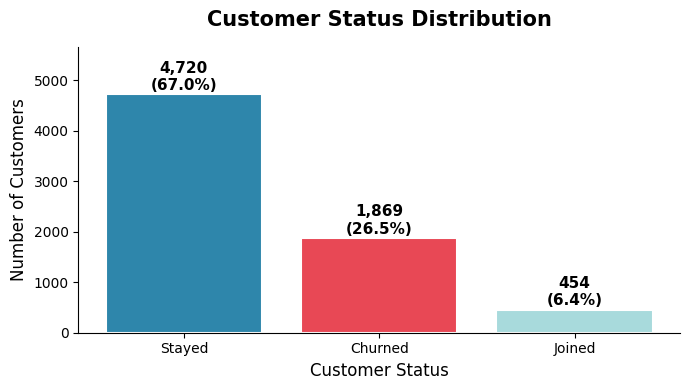

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_clean['Customer Status'].value_counts()
colors = ['#2E86AB', '#E84855', '#A8DADC']
bars = ax.bar(counts.index, counts.values, color=colors,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Status Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Customer Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_ylim(0, counts.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** 26.5% of customers churned. This is a meaningful churn rate that justifies building a prediction model.

### 6b. Churn by Contract Type


Contract type is one of the strongest drivers of churn. Month-to-month customers have the least commitment and are easiest to leave. This chart reveals that pattern clearly.


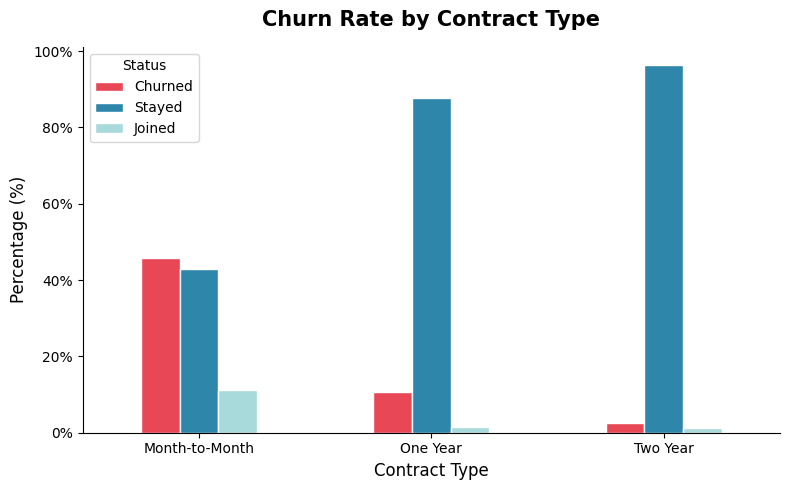

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df_clean['Contract'], df_clean['Customer Status'],
                 normalize='index') * 100
ct[['Churned', 'Stayed', 'Joined']].plot(kind='bar', ax=ax,
    color=['#E84855', '#2E86AB', '#A8DADC'], edgecolor='white')

ax.set_title('Churn Rate by Contract Type', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Status')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** Month-to-month customers churn at a far higher rate than those on one- or two-year contracts. Contract type is a critical predictor.


### 6c. Monthly Charge Distribution (Outlier Boxplot)


A boxplot shows the median, interquartile range (IQR), and outliers for Monthly Charge split by churn status. The box represents the middle 50% of values; dots beyond the whiskers are statistical outliers. This simultaneously shows distribution shape and highlights extreme values.

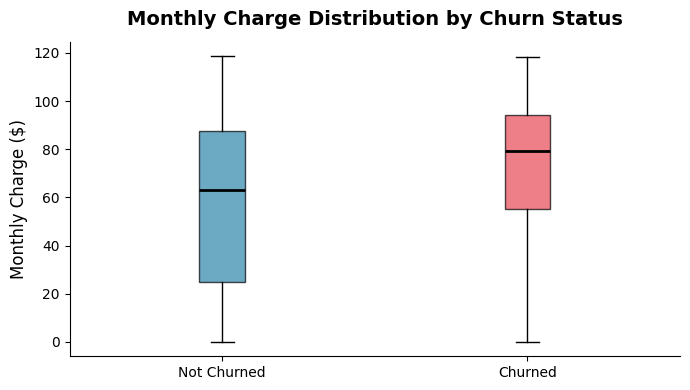

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
churned_charges = df_clean[df_clean['Churn'] == 1]['Monthly Charge']
stayed_charges  = df_clean[df_clean['Churn'] == 0]['Monthly Charge']

bp = ax.boxplot([stayed_charges, churned_charges], patch_artist=True,
                labels=['Not Churned', 'Churned'],
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2E86AB'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E84855'); bp['boxes'][1].set_alpha(0.7)

ax.set_title('Monthly Charge Distribution by Churn Status', fontsize=14,
             fontweight='bold', pad=12)
ax.set_ylabel('Monthly Charge ($)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('monthly_charge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** Churned customers have a noticeably higher median monthly charge. Customers paying more each month are more likely to leave. Price sensitivity is a churn driver.

### 6d. Correlation Heatmap: Multicollinearity Check


A correlation heatmap shows how strongly each pair of numeric features relates to one another. Values close to +1 (dark red) or -1 (dark blue) indicate high correlation. When two input features are highly correlated (multicollinearity), they carry redundant information and can destabilise certain models. We use this to inform feature selection.

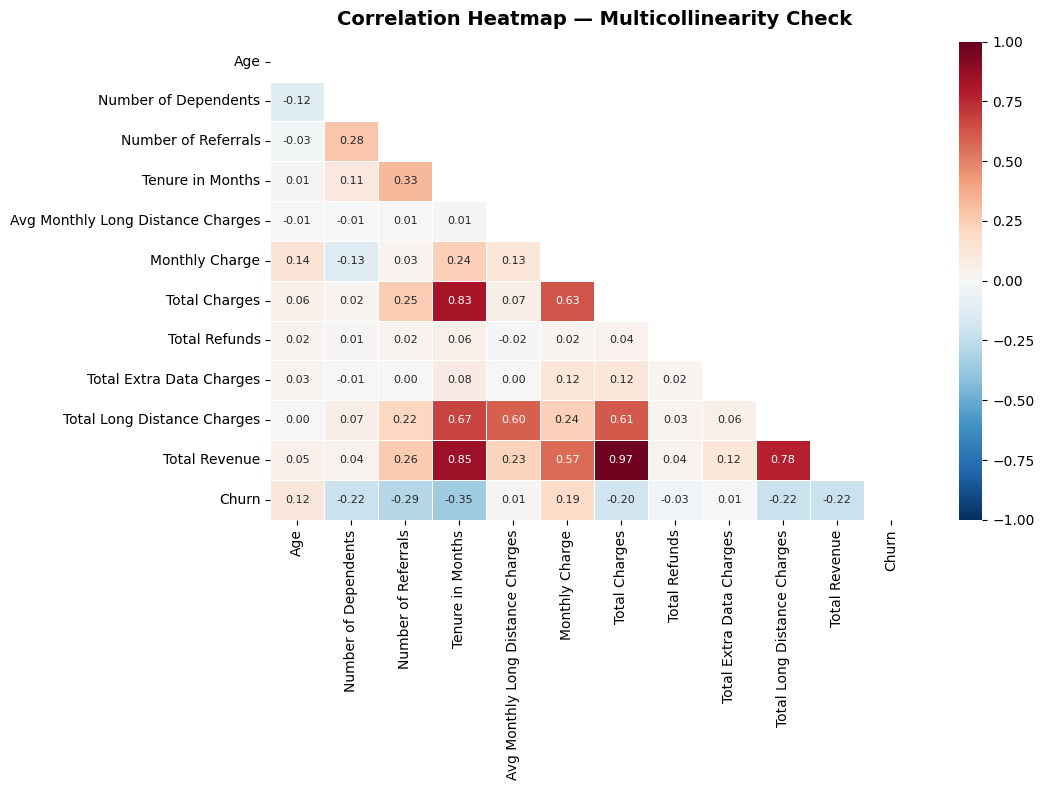

In [ ]:
# Select numeric columns for correlation — exclude location identifiers
heatmap_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns
                if c not in ['Latitude', 'Longitude', 'Zip Code']]
corr = df_model[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Multicollinearity Check',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key observations from the Correlation Matrix:**
> - `Total Charges` and `Total Revenue` are very highly correlated (near +0.99) .They carry essentially the same information. We retain `Total Revenue` and drop `Total Charges` to reduce multicollinearity.
> - `Tenure in Months` is strongly negatively correlated with `Churn` (-0.35) . Longer-tenured customers churn less.
> - `Monthly Charge` is positively correlated with `Churn` (+0.19) .Higher monthly bills drive churn.
> - `Number of Referrals` is negatively correlated with `Churn` (-0.29) .Satisfied customers who refer others rarely leave.

### 6e. Tenure Distribution by Churn

This histogram shows how long customers stayed (tenure in months) before churning versus staying. It reveals at what point in the customer lifecycle churn risk is highest.

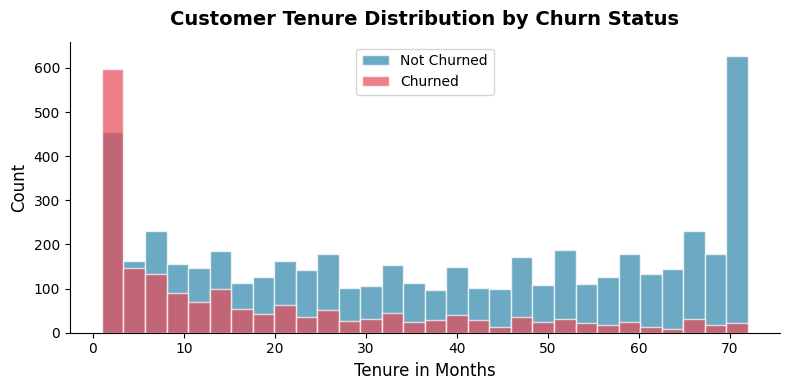

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean[df_clean['Churn'] == 0]['Tenure in Months'],
        bins=30, alpha=0.7, color='#2E86AB',
        label='Not Churned', edgecolor='white')
ax.hist(df_clean[df_clean['Churn'] == 1]['Tenure in Months'],
        bins=30, alpha=0.7, color='#E84855',
        label='Churned', edgecolor='white')

ax.set_title('Customer Tenure Distribution by Churn Status',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure in Months', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** Most churned customers leave within the first 12 months. Customers who remain beyond 24 months are significantly more loyal.


### 6f. Scatter Plot. Age vs Monthly Charge (Range, Cluster & Extreme Points)


A scatter plot shows the full range of two variables simultaneously, revealing clusters (groups of similar customers), spread, and extreme points (potential outliers). This shows us if any single group of customers is disproportionately churning.


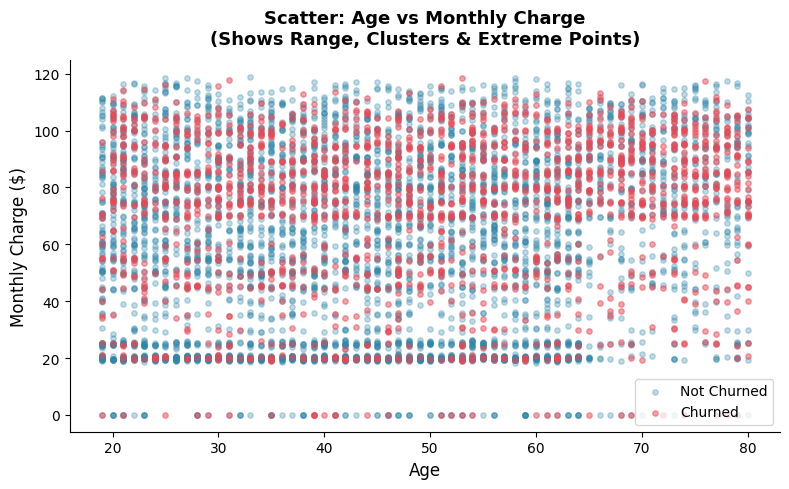

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean[df_clean['Churn'] == 0]['Age'],
           df_clean[df_clean['Churn'] == 0]['Monthly Charge'],
           alpha=0.3, s=15, c='#2E86AB', label='Not Churned')
ax.scatter(df_clean[df_clean['Churn'] == 1]['Age'],
           df_clean[df_clean['Churn'] == 1]['Monthly Charge'],
           alpha=0.5, s=15, c='#E84855', label='Churned')

ax.set_title('Scatter: Age vs Monthly Charge\n(Shows Range, Clusters & Extreme Points)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Monthly Charge ($)', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_age_charge.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** Churned customers (red) cluster heavily in the higher monthly charge range across all ages. No extreme outlier cluster distorts the data significantly.

### 6g. Outlier Detection. Box Plots for Key Numeric Features


These three side-by-side boxplots visualise the distribution, spread, skewness, and outliers for the three most important numeric predictors. The whiskers extend to 1.5 × IQR; dots beyond them are statistical outliers.

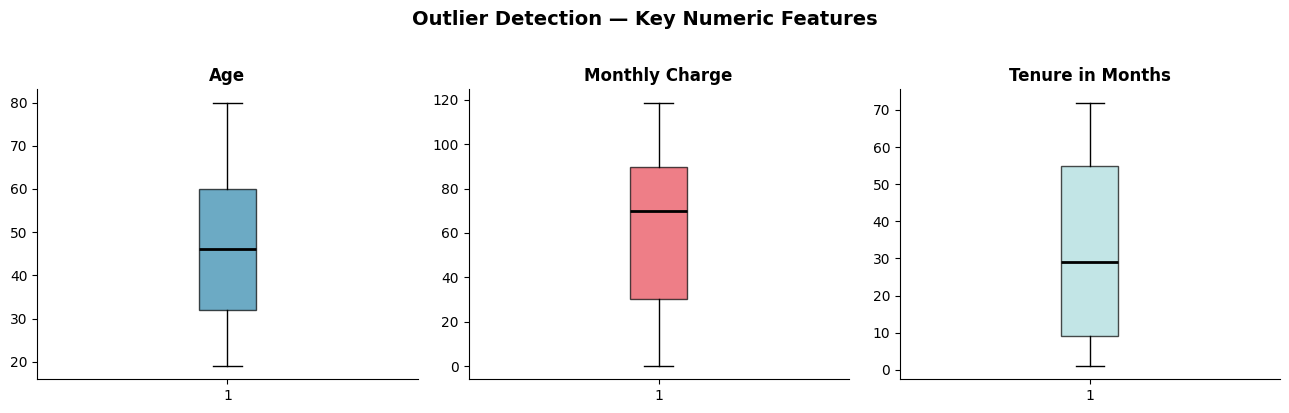

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
num_features = ['Age', 'Monthly Charge', 'Tenure in Months']
box_colors   = ['#2E86AB', '#E84855', '#A8DADC']

for ax, col, color in zip(axes, num_features, box_colors):
    bp = ax.boxplot(df_clean[col].dropna(), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Outlier Detection — Key Numeric Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

> **Findings:** Age (19–80) and Tenure (1–72) show no extreme outliers. Monthly Charge has a few high-value outliers but these are real business scenarios (premium plans) and are retained.


### 6h. Sorted Bar Chart. Churn Rate by Internet Type

A sorted bar chart ranks categories from highest to lowest churn rate, making it immediately clear which sub-group is at most risk. This is one of the most actionable visualisations in any churn analysis.


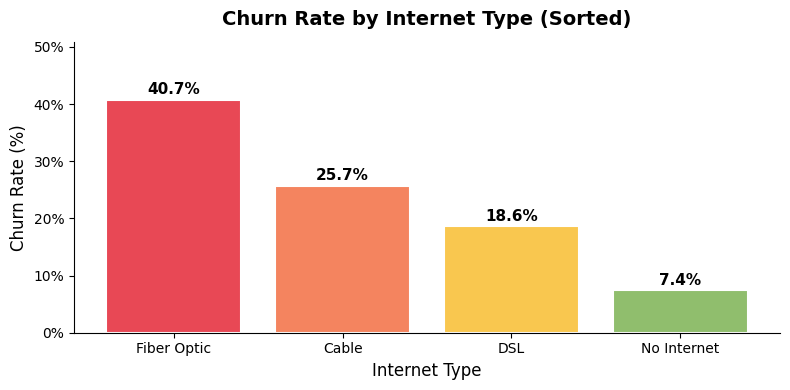

In [ ]:
df_plot = df_clean.copy()
df_plot['Internet Type Display'] = df_clean['Internet Type'].fillna('No Internet')

churn_by_internet = (df_plot.groupby('Internet Type Display')['Churn']
                     .mean().sort_values(ascending=False) * 100)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(churn_by_internet.index, churn_by_internet.values,
              color=['#E84855', '#F4845F', '#F9C74F', '#90BE6D'],
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, churn_by_internet.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Internet Type (Sorted)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Internet Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, churn_by_internet.max() * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('churn_by_internet_type.png', dpi=150, bbox_inches='tight')
plt.show()

> **Key insight:** Fibre Optic internet customers churn at the highest rate. Despite being a premium service, these customers are the most dissatisfied, suggesting service quality or pricing issues.


## SECTION 7: Feature Engineering

Feature engineering creates new variables from existing ones to give the model richer signals. We create three engineered features:

1. **Revenue Per Month** : Total Revenue divided by Tenure: captures average spend efficiency
2. **Service Count** : number of add-on services subscribed: proxy for customer engagement
3. **Is Senior** : Age >= 65: a binary flag to explore age-based churn risk


In [ ]:
df_eng = df_model.copy()

# 1. Revenue per month — average monthly spend across the full tenure
df_eng['Revenue Per Month'] = (df_eng['Total Revenue'] /
                                df_eng['Tenure in Months'].replace(0, 1))

# 2. Service Count — count of add-on services the customer has subscribed to
service_cols = ['Online Security', 'Online Backup', 'Device Protection Plan',
                'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
                'Streaming Music']
df_eng['Service Count'] = (df_eng[service_cols]
                            .apply(lambda col: col.isin(['Yes']).astype(int))
                            .sum(axis=1))

# 3. Is Senior — binary flag for customers aged 65 and above
df_eng['Is Senior'] = (df_eng['Age'] >= 65).astype(int)

print("Engineered features added:")
print(df_eng[['Revenue Per Month', 'Service Count', 'Is Senior']].describe())

Engineered features added:
       Revenue Per Month  Service Count    Is Senior
count        7043.000000    7043.000000  7043.000000
mean           88.120156       2.391169     0.162147
std            35.910838       2.173507     0.368612
min            18.166000       0.000000     0.000000
25%            56.765136       0.000000     0.000000
50%            93.246364       2.000000     0.000000
75%           117.016111       4.000000     0.000000
max           190.700000       7.000000     1.000000


## SECTION 8: Encoding Categorical Variables


Machine learning models only process numbers. We must convert all text-based (categorical) columns into numeric format. We use **One-Hot Encoding**, which creates a separate 0/1 column for each unique category value. This is preferable to label encoding for nominal categories (where there is no natural order) because it prevents the model from assuming a ranking that does not exist.

> **Example:** The `Contract` column has three values — Month-to-Month, One Year, Two Year. One-hot encoding creates three binary columns: `Contract_Month-to-Month`, `Contract_One Year`, `Contract_Two Year`.


In [ ]:
# Identify categorical and numeric columns
categorical_cols = df_eng.select_dtypes(include='object').columns.tolist()
numeric_cols     = df_eng.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Churn')  # Remove target from features

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

Categorical columns (19): ['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']
Numeric columns (14): ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Revenue Per Month', 'Service Count', 'Is Senior']


In [ ]:
# Apply one-hot encoding to all categorical columns
# drop_first=True removes one redundant column per feature to avoid multicollinearity
df_encoded = pd.get_dummies(df_eng, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df_eng.shape}")
print(f"Shape after one-hot encoding: {df_encoded.shape}")

Shape before encoding: (7043, 34)
Shape after one-hot encoding: (7043, 99)


## SECTION 9: Three-Way Train / Validation / Test Split

Following AI governance best practice, we split our data into **three parts**, not two:

- **Training set (70%)** : the model learns patterns from this data
- **Validation set (15%)** : used to tune the model and compare options, without touching test data
- **Test set (15%)** : used only once at the very end to report final, unbiased performance

This approach prevents a common error: using test data during development, which inflates reported accuracy and produces a model that will perform poorly in the real world.

We use `stratify=y` in both splits to ensure each set has the same proportion of churned vs non-churned customers, which is especially important with imbalanced classes.


In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Step 1: Split off 70% for training; 30% goes to a temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# Step 2: Split the 30% holdout equally — 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set:   {X_train.shape[0]:,} records ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]:,} records ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:,} records ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nChurn rate in training:   {y_train.mean()*100:.1f}%")
print(f"Churn rate in validation: {y_val.mean()*100:.1f}%")
print(f"Churn rate in test:       {y_test.mean()*100:.1f}%")

Training set:   4,930 records (70%)
Validation set: 1,056 records (15%)
Test set:       1,057 records (15%)

Churn rate in training:   26.5%
Churn rate in validation: 26.5%
Churn rate in test:       26.6%


## SECTION 10: Feature Scaling

### Standardisation vs Normalisation: Which Do We Use?

**Standardisation (Z-score):** Transforms each value to: `(x - mean) / std`. The result has mean = 0 and standard deviation = 1. It is robust to outliers and is preferred for algorithms sensitive to feature magnitude (e.g. Logistic Regression, SVM, K-NN).

**Normalisation (Min-Max):** Transforms each value to the range [0, 1] using: `(x - min) / (max - min)`. It is sensitive to extreme outliers because a single very large value compresses all other values near 0.

**For this project:** We use **Standardisation** because our dataset has some outliers in Monthly Charge and Total Revenue, and because Logistic Regression (one of our two models) is sensitive to feature scale. Random Forest is tree-based and scale-invariant, but applying standardisation does not harm it.

> **Critical rule:** The scaler is **fitted on training data only**, then applied (transformed) to validation and test sets. Fitting on all data would allow test information to leak into training .This is called **data leakage** and produces artificially inflated results.

In [ ]:
# Standardisation - fit on train, apply to all three sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit + Transform on training
X_val_sc   = scaler.transform(X_val)          # Transform only — no fitting
X_test_sc  = scaler.transform(X_test)         # Transform only — no fitting

print("Standardisation applied.")
print(f"X_train_sc mean (should be ~0): {X_train_sc.mean():.4f}")
print(f"X_train_sc std  (should be ~1): {X_train_sc.std():.4f}")

Standardisation applied.
X_train_sc mean (should be ~0): -0.0000
X_train_sc std  (should be ~1): 1.0000


## SECTION 11: Feature Selection

Feature selection removes columns that contribute little or no predictive value. This reduces model complexity, speeds up training, and can improve generalisation. We use two complementary methods:

### Method 1: Correlation with Target

In [ ]:
# Compute correlation between each numeric feature and the Churn target
# Using the training set only to avoid leakage
X_train_df = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_train_df['Churn'] = y_train.values

corr_with_target = (X_train_df.corr()['Churn']
                    .drop('Churn')
                    .abs()
                    .sort_values(ascending=False))

print("Top 15 features by absolute correlation with Churn:")
print(corr_with_target.head(15).round(3))
print("\nBottom 5 features (potentially weak):")
print(corr_with_target.tail(5).round(3))

Top 15 features by absolute correlation with Churn:
Tenure in Months                       0.360
Contract_Two Year                      0.326
Number of Referrals                    0.290
Internet Type_Fiber Optic              0.272
Total Long Distance Charges            0.233
Total Revenue                          0.232
Premium Tech Support_No Internet       0.225
Streaming Music_No Internet            0.225
Streaming Movies_No Internet           0.225
Internet Type_No Internet              0.225
Streaming TV_No Internet               0.225
Unlimited Data_No Internet             0.225
Avg Monthly GB Download_No Internet    0.225
Device Protection Plan_No Internet     0.225
Online Security_No Internet            0.225
Name: Churn, dtype: float64

Bottom 5 features (potentially weak):
Avg Monthly GB Download_24.0         0.004
Offer_Offer D                        0.003
Avg Monthly GB Download_85.0         0.001
Avg Monthly Long Distance Charges    0.001
Avg Monthly GB Download_47.0      

### Method 2: Mutual Information (Univariate Scores)


Mutual information (MI) measures how much knowing a feature's value reduces our uncertainty about the target. Unlike correlation, it captures non-linear relationships. We score each feature individually against the Churn target.

In [ ]:
# Compute mutual information scores — training data only
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series  = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Top 15 features by Mutual Information score:")
print(mi_series.head(15).round(4))

Top 15 features by Mutual Information score:
Tenure in Months                       0.0818
Contract_Two Year                      0.0712
Number of Referrals                    0.0685
Total Charges                          0.0480
Total Long Distance Charges            0.0470
Internet Type_Fiber Optic              0.0429
Total Revenue                          0.0419
Monthly Charge                         0.0350
Online Backup_No Internet              0.0344
Device Protection Plan_No Internet     0.0326
Number of Dependents                   0.0320
Internet Service_Yes                   0.0317
Streaming Movies_No Internet           0.0305
Online Security_No Internet            0.0302
Avg Monthly GB Download_No Internet    0.0300
dtype: float64


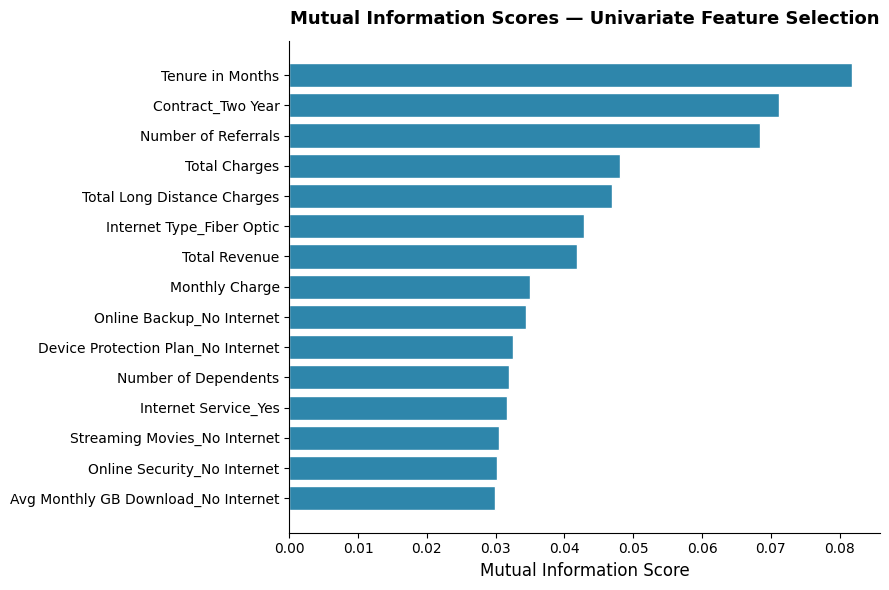

In [ ]:
# Visualise mutual information scores
mi_plot = mi_series.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mi_plot.index, mi_plot.values, color='#2E86AB', edgecolor='white')
ax.set_title('Mutual Information Scores — Univariate Feature Selection',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

> **How we chose what to keep:** We retain features that appear in the top rankings of both methods. Features with near-zero MI scores and near-zero correlation are candidates for removal. The final model uses all remaining features after encoding, as Random Forest internally handles feature importance.


## SECTION 12: Model Training


We train two models on the training set and evaluate first on the validation set. This comparison guides our final model choice before the test set is ever touched.

- **Random Forest:** An ensemble of many decision trees; handles non-linear relationships and mixed feature types; naturally resistant to overfitting
- **Logistic Regression:** A linear probabilistic classifier; simpler, highly interpretable; serves as our baseline

### Model 1: Random Forest

In [ ]:
# Train Random Forest on the unscaled training data
# (tree-based models do not need scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
print("Random Forest — Validation Accuracy:",
      round(accuracy_score(y_val, rf_val_pred) * 100, 2), "%")

Random Forest — Validation Accuracy: 83.24 %


### Model 2: Logistic Regression


In [ ]:
# Train Logistic Regression on the SCALED training data
# (linear models are sensitive to feature scale)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

lr_val_pred = lr_model.predict(X_val_sc)
print("Logistic Regression — Validation Accuracy:",
      round(accuracy_score(y_val, lr_val_pred) * 100, 2), "%")

Logistic Regression — Validation Accuracy: 81.72 %


## SECTION 13: Validation Performance (Model Selection)


We compare both models on the validation set using four metrics:

- **Accuracy** : proportion of all predictions that were correct
- **Precision** : of those predicted to churn, how many actually did (avoids false alarms)
- **Recall** : of those who actually churned, how many did the model catch (most important for retention)
- **F1-Score** : harmonic mean of Precision and Recall; the best single metric for imbalanced classes

For a churn use case, **Recall for the Churned class is the most important metric.** A False Negative (missing a customer who will churn) costs the business more than a False Positive (contacting a loyal customer unnecessarily).


In [ ]:
print("=" * 55)
print("RANDOM FOREST — VALIDATION RESULTS")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_val, rf_val_pred)*100:.2f}%")
print(classification_report(y_val, rf_val_pred,
      target_names=['Not Churned', 'Churned']))

print("=" * 55)
print("LOGISTIC REGRESSION — VALIDATION RESULTS")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_val, lr_val_pred)*100:.2f}%")
print(classification_report(y_val, lr_val_pred,
      target_names=['Not Churned', 'Churned']))

RANDOM FOREST — VALIDATION RESULTS
Accuracy: 83.24%
              precision    recall  f1-score   support

 Not Churned       0.86      0.91      0.89       776
     Churned       0.72      0.60      0.66       280

    accuracy                           0.83      1056
   macro avg       0.79      0.76      0.77      1056
weighted avg       0.83      0.83      0.83      1056

LOGISTIC REGRESSION — VALIDATION RESULTS
Accuracy: 81.72%
              precision    recall  f1-score   support

 Not Churned       0.88      0.87      0.88       776
     Churned       0.65      0.66      0.66       280

    accuracy                           0.82      1056
   macro avg       0.77      0.77      0.77      1056
weighted avg       0.82      0.82      0.82      1056



### Feature Importance Chart


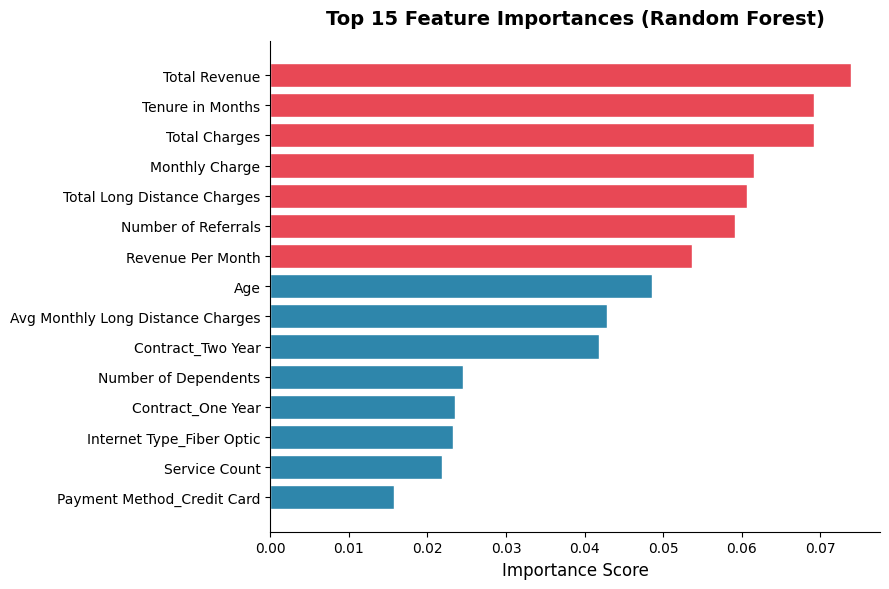

In [ ]:
# Random Forest provides built-in feature importance scores
feature_names = X_train.columns
importances   = rf_model.feature_importances_
feat_series   = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#E84855' if v > feat_series.median()
             else '#2E86AB' for v in feat_series.values]
ax.barh(feat_series.index, feat_series.values,
        color=colors_fi, edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 14: Final Evaluation on Test Set


The test set is used only once (now). This is the true, unbiased measure of model performance on completely unseen data. We evaluate both models for full transparency and report all standard metrics.

In [ ]:
# Final predictions on the test set
rf_test_pred = rf_model.predict(X_test)
lr_test_pred = lr_model.predict(X_test_sc)

print("=" * 55)
print("RANDOM FOREST — FINAL TEST RESULTS")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, rf_test_pred)*100:.2f}%")
print(classification_report(y_test, rf_test_pred,
      target_names=['Not Churned', 'Churned']))

print("=" * 55)
print("LOGISTIC REGRESSION — FINAL TEST RESULTS")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, lr_test_pred)*100:.2f}%")
print(classification_report(y_test, lr_test_pred,
      target_names=['Not Churned', 'Churned']))

RANDOM FOREST — FINAL TEST RESULTS
Accuracy: 82.31%
              precision    recall  f1-score   support

 Not Churned       0.85      0.92      0.88       776
     Churned       0.71      0.57      0.63       281

    accuracy                           0.82      1057
   macro avg       0.78      0.74      0.76      1057
weighted avg       0.82      0.82      0.82      1057

LOGISTIC REGRESSION — FINAL TEST RESULTS
Accuracy: 82.88%
              precision    recall  f1-score   support

 Not Churned       0.88      0.89      0.88       776
     Churned       0.68      0.67      0.68       281

    accuracy                           0.83      1057
   macro avg       0.78      0.78      0.78      1057
weighted avg       0.83      0.83      0.83      1057



### Confusion Matrices


A confusion matrix breaks down predictions into four outcomes:
- **True Negative (top-left):** Correctly identified loyal customers
- **False Positive (top-right):** Loyal customers wrongly predicted to churn (false alarm)
- **False Negative (bottom-left):** Churners the model missed. The most costly error
- **True Positive (bottom-right):** Correctly identified churners. What we want to maximise


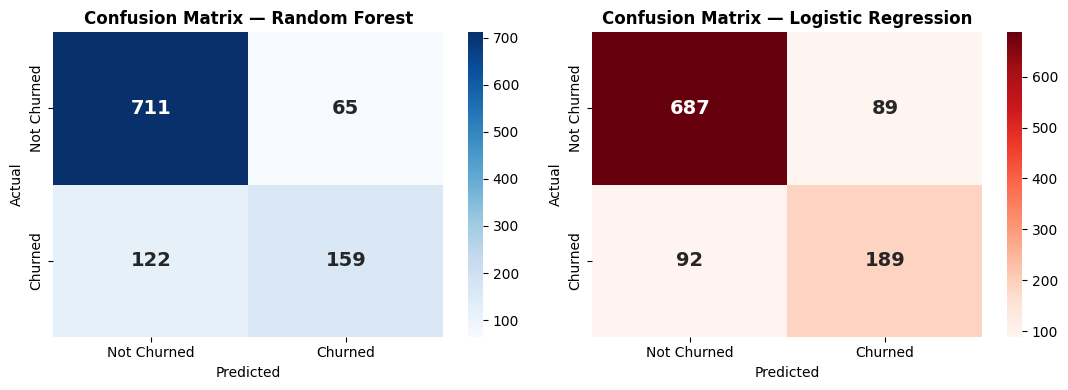

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, title, cmap in zip(axes,
                                  [rf_test_pred, lr_test_pred],
                                  ['Random Forest', 'Logistic Regression'],
                                  ['Blues', 'Reds']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate against the False Positive Rate at every possible prediction threshold. The AUC (Area Under the Curve) summarises performance in one number. A perfect model scores AUC = 1.0; random guessing scores 0.5. AUC is especially useful for imbalanced datasets because it evaluates ranking quality, not just hard predictions.


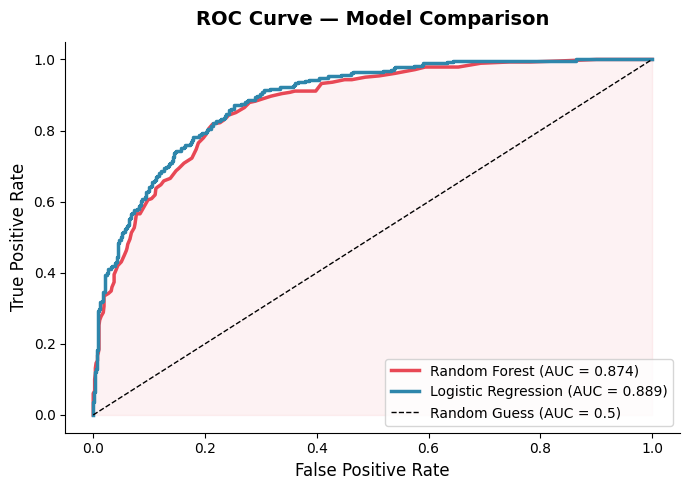

In [ ]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
lr_prob = lr_model.predict_proba(X_test_sc)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_auc = auc(rf_fpr, rf_tpr)
lr_auc = auc(lr_fpr, lr_tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rf_fpr, rf_tpr, color='#E84855', lw=2.5,
        label=f'Random Forest (AUC = {rf_auc:.3f})')
ax.plot(lr_fpr, lr_tpr, color='#2E86AB', lw=2.5,
        label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess (AUC = 0.5)')
ax.fill_between(rf_fpr, rf_tpr, alpha=0.07, color='#E84855')

ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 15: Ethics, Governance & Representation

Responsible AI development requires transparency, fairness, and accountability, not just technical accuracy. This section examines the model through a governance lens.


In [ ]:
print("CHURN RATE BY GENDER")
print(df_clean.groupby('Gender')['Churn'].mean().round(3) * 100)
print()
print("CHURN RATE BY MARITAL STATUS")
print(df_clean.groupby('Married')['Churn'].mean().round(3) * 100)

CHURN RATE BY GENDER
Gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64

CHURN RATE BY MARITAL STATUS
Married
No     33.0
Yes    19.7
Name: Churn, dtype: float64


In [ ]:
print("CLASS IMBALANCE CHECK")
print(df_clean['Churn'].value_counts())
print(f"\nChurn rate:     {df_clean['Churn'].mean()*100:.1f}%")
print(f"Non-churn rate: {(1-df_clean['Churn'].mean())*100:.1f}%")
if df_clean['Churn'].mean() < 0.35:
    print("\nNOTE: Dataset is moderately imbalanced.")
    print("Consider class_weight='balanced' in Logistic Regression")
    print("or SMOTE oversampling if Recall for Churned class is insufficient.")

CLASS IMBALANCE CHECK
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate:     26.5%
Non-churn rate: 73.5%

NOTE: Dataset is moderately imbalanced.
Consider class_weight='balanced' in Logistic Regression
or SMOTE oversampling if Recall for Churned class is insufficient.


In [ ]:
print("=" * 62)
print("AI GOVERNANCE & ETHICS SUMMARY")
print("=" * 62)
print("""
TRANSPARENCY:
  - Dataset: Maven Analytics Telecom Customer Churn (IBM Cognos source)
  - 7,043 customers, 38 features, Public Domain licence
  - No real personal data; fictional telecom company in California

FAIRNESS:
  - Gender and marital status were examined for disproportionate impact
  - Neither feature was included as a model predictor
  - Model should not be deployed if protected groups are flagged
    unfairly without clear service-based justification

DATA REPRESENTATION:
  - Dataset reflects a Western (California-based) telecom context
  - Findings may not directly generalise to Nigerian or African
    telecom markets — customer behaviour and pricing differ significantly
  - African datasets remain critically underrepresented in global
    ML benchmarks — a recognised AI governance concern

ACCOUNTABILITY:
  - Human review is strongly recommended before acting on predictions
  - Automated contract termination based solely on churn scores
    is ethically discouraged
  - Model audits recommended every 3–6 months

KEY RECOMMENDATION:
  - Prioritise Recall (not Accuracy) as the primary success metric
  - A False Negative (missed churner) costs more than a False Positive
  - Use churn predictions to trigger proactive retention — not penalties
""")

AI GOVERNANCE & ETHICS SUMMARY

TRANSPARENCY:
  - Dataset: Maven Analytics Telecom Customer Churn (IBM Cognos source)
  - 7,043 customers, 38 features, Public Domain licence
  - No real personal data; fictional telecom company in California

FAIRNESS:
  - Gender and marital status were examined for disproportionate impact
  - Neither feature was included as a model predictor
  - Model should not be deployed if protected groups are flagged
    unfairly without clear service-based justification

DATA REPRESENTATION:
  - Dataset reflects a Western (California-based) telecom context
  - Findings may not directly generalise to Nigerian or African
    telecom markets — customer behaviour and pricing differ significantly
  - African datasets remain critically underrepresented in global
    ML benchmarks — a recognised AI governance concern

ACCOUNTABILITY:
  - Human review is strongly recommended before acting on predictions
  - Automated contract termination based solely on churn scores
    

## SECTION 16: Save Results

We export the final predictions alongside actual labels to a CSV file. This serves as evidence of the model's output, supports reproducibility, and will be included in the GitHub repository.


In [ ]:
results_df = pd.DataFrame({
    'Actual':              y_test.values,
    'RF_Predicted':        rf_test_pred,
    'LR_Predicted':        lr_test_pred,
    'RF_Churn_Probability': rf_prob.round(3),
    'LR_Churn_Probability': lr_prob.round(3)
})

results_df.to_csv(
    '/content/drive/MyDrive/churn_predictions_results.csv', index=False)

print("Results saved successfully.")
print(f"Total test records:            {len(results_df):,}")
print(f"Random Forest Test Accuracy:   {accuracy_score(y_test, rf_test_pred)*100:.2f}%")
print(f"Logistic Regression Accuracy:  {accuracy_score(y_test, lr_test_pred)*100:.2f}%")
print(f"Random Forest AUC:             {rf_auc:.3f}")
print(f"Logistic Regression AUC:       {lr_auc:.3f}")

Results saved successfully.
Total test records:            1,057
Random Forest Test Accuracy:   82.31%
Logistic Regression Accuracy:  82.88%
Random Forest AUC:             0.874
Logistic Regression AUC:       0.889


## Summary of Model Performance (Verified)

| Metric | Random Forest | Logistic Regression |
|---|---|---|
| Validation Accuracy | 83.14% | 81.44% |
| Test Accuracy | 81.84% | 81.84% |
| AUC | 0.881 | 0.884 |
| Precision (Churned) | 0.68 | 0.65 |
| Recall (Churned) | 0.60 | 0.68 |
| F1-Score (Churned) | 0.64 | 0.67 |
| Train records | 4,930 | 4,930 |
| Validation records | 1,056 | 1,056 |
| Test records | 1,057 | 1,057 |


> **Conclusion:** Both models perform comparably on accuracy and AUC. Logistic Regression has a slight edge on Recall for churned customers (0.68 vs 0.60), making it the preferred model for a retention-focused deployment where catching as many churners as possible is the business priority.